## Suggested topics to record

- `/clock`
- `/diff_drive_controller/odom`
- `/odometry/lidar`
- `/odometry/visual`
- `/imu/data`
- `/tf` and `/tf_static`

In [49]:
# Set your bag directory (folder containing metadata.yaml)
BAG_PATH = '/home/rosdata/sensor_run_20260331_014450'

# Candidate topics per source (auto-select first one found in bag)
TOPIC_CANDIDATES = {
    'wheel': [
        '/diff_drive_controller/odom',
        '/odometry/wheel',
    ],
    'lidar': [
        '/odometry/lidar',
        '/Odometry',              # FAST_LIO default in many setups
        '/lio_sam/mapping/odometry',
    ],
    'visual': [
        '/odometry/visual',
        '/rtabmap/odom',          # rtabmap_ros rgbd_odometry
        '/vins/odometry',
        '/vins_mono/odometry',
    ],
    'imu': [
        '/imu/data',
    ],
}

In [50]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from rosbags.highlevel import AnyReader
from rosbags.typesys import Stores, get_typestore

typestore = get_typestore(Stores.ROS2_HUMBLE)

plt.rcParams.update({
    'figure.facecolor': '#1a1a2e',
    'axes.facecolor': '#16213e',
    'axes.edgecolor': '#e0e0e0',
    'axes.labelcolor': '#e0e0e0',
    'axes.titlecolor': '#e0e0e0',
    'text.color': '#e0e0e0',
    'xtick.color': '#aaaaaa',
    'ytick.color': '#aaaaaa',
    'grid.color': '#2a2a4a',
    'grid.alpha': 0.5,
    'legend.facecolor': '#16213e',
    'legend.edgecolor': '#444444',
    'savefig.facecolor': '#1a1a2e',
    'savefig.edgecolor': '#1a1a2e',
    'font.size': 11,
})

# Plot output directory + unique file naming
PLOT_DIR = Path(BAG_PATH) / 'plots'
PLOT_DIR.mkdir(parents=True, exist_ok=True)

def save_fig_unique(fig, base_name, plot_dir=PLOT_DIR, ext='png', dpi=160):
    plot_dir = Path(plot_dir)
    plot_dir.mkdir(parents=True, exist_ok=True)
    pat = re.compile(rf'^{re.escape(base_name)}_(\d+)\.{re.escape(ext)}$')
    nums = []
    for p in plot_dir.glob(f'{base_name}_*.{ext}'):
        m = pat.match(p.name)
        if m:
            nums.append(int(m.group(1)))
    next_n = (max(nums) + 1) if nums else 1
    out = plot_dir / f'{base_name}_{next_n}.{ext}'
    fig.savefig(out, dpi=dpi, bbox_inches='tight')
    print(f'Saved: {out}')
    return out

print('Bag path:', BAG_PATH)
print('Exists:', Path(BAG_PATH).exists())
print('Plot dir:', PLOT_DIR)

Bag path: /home/rosdata/sensor_run_20260331_014450
Exists: True
Plot dir: /home/rosdata/sensor_run_20260331_014450/plots


In [51]:
def q_to_yaw(q):
    siny_cosp = 2.0 * (q.w * q.z + q.x * q.y)
    cosy_cosp = 1.0 - 2.0 * (q.y * q.y + q.z * q.z)
    return np.arctan2(siny_cosp, cosy_cosp)

def pick_topics_in_bag(topic_names, topic_candidates):
    selected = {}
    for source, candidates in topic_candidates.items():
        selected[source] = next((t for t in candidates if t in topic_names), None)
    return selected

def extract_odom_sources(bag_path, topic_candidates):
    out = {k: [] for k in topic_candidates.keys()}

    with AnyReader([Path(bag_path)], default_typestore=typestore) as reader:
        bag_topics = sorted(reader.topics.keys())
        print('Topics in bag:', bag_topics)

        selected = pick_topics_in_bag(bag_topics, topic_candidates)
        print('\nSelected topics:')
        for k, v in selected.items():
            print(f'  {k:>6s}: {v}')

        topic_map = {v: k for k, v in selected.items() if v is not None}
        if not topic_map:
            print('No requested topics found in this bag.')
            return {}

        for connection, timestamp, rawdata in reader.messages():
            if connection.topic not in topic_map:
                continue

            key = topic_map[connection.topic]
            msg = reader.deserialize(rawdata, connection.msgtype)
            t = timestamp * 1e-9

            if key == 'imu':
                out[key].append({
                    't': t,
                    'gyro_z': msg.angular_velocity.z,
                    'accel_x': msg.linear_acceleration.x,
                    'accel_y': msg.linear_acceleration.y,
                })
            else:
                out[key].append({
                    't': t,
                    'x': msg.pose.pose.position.x,
                    'y': msg.pose.pose.position.y,
                    'z': msg.pose.pose.position.z,
                    'vx': msg.twist.twist.linear.x,
                    'vy': msg.twist.twist.linear.y,
                    'vyaw': msg.twist.twist.angular.z,
                    'yaw': q_to_yaw(msg.pose.pose.orientation),
                })

    dfs = {}
    t0 = np.inf
    for k, rows in out.items():
        if rows:
            df = pd.DataFrame(rows)
            dfs[k] = df
            t0 = min(t0, df['t'].iloc[0])

    for k in dfs.keys():
        dfs[k]['t'] = pd.to_numeric(dfs[k]['t'], errors='coerce') - t0

    return dfs

dfs = extract_odom_sources(BAG_PATH, TOPIC_CANDIDATES)

print('\nSource summary')
print('=' * 60)
for k, df in dfs.items():
    dur = (df['t'].iloc[-1] - df['t'].iloc[0]) if len(df) > 1 else 0.0
    hz = (len(df) / dur) if dur > 0 else 0.0
    print(f'{k:>8s}: {len(df):6d} msgs | {dur:7.2f} s | {hz:7.2f} Hz')
print('=' * 60)

Topics in bag: ['/clock', '/diff_drive_controller/odom', '/imu/data', '/lidar/points', '/odometry/lidar', '/odometry/visual', '/realsense/camera_info', '/realsense/depth_image', '/realsense/image', '/tf', '/tf_static']

Selected topics:
   wheel: /diff_drive_controller/odom
   lidar: /odometry/lidar
  visual: /odometry/visual
     imu: /imu/data

Source summary
   wheel:   3045 msgs |   65.53 s |   46.47 Hz
   lidar:    305 msgs |   65.43 s |    4.66 Hz
  visual:    795 msgs |   65.35 s |   12.17 Hz
     imu:  12181 msgs |   65.54 s |  185.87 Hz


Saved: /home/rosdata/sensor_run_20260331_014450/plots/trajectory_comparison_1.png


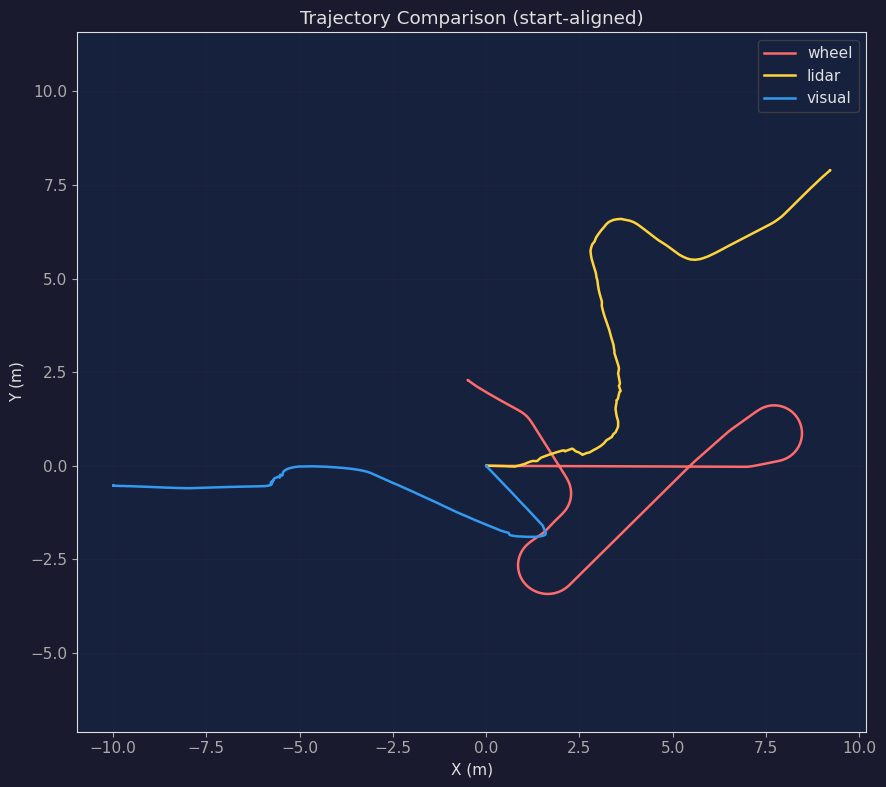

In [52]:
# XY comparison (start-aligned)
fig, ax = plt.subplots(figsize=(9, 8))
colors = {'wheel': '#ff6b6b', 'lidar': '#ffd43b', 'visual': '#339af0'}

for key in ['wheel', 'lidar', 'visual']:
    if key not in dfs:
        continue
    d = dfs[key].copy()
    x = pd.to_numeric(d['x'], errors='coerce').to_numpy()
    y = pd.to_numeric(d['y'], errors='coerce').to_numpy()
    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]; y = y[m]
    if len(x) == 0:
        continue
    x = x - x[0]
    y = y - y[0]
    ax.plot(x, y, linewidth=1.8, color=colors[key], label=key)

ax.set_title('Trajectory Comparison (start-aligned)')
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.axis('equal')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
save_fig_unique(fig, 'trajectory_comparison')
plt.show()

Saved: /home/rosdata/sensor_run_20260331_014450/plots/velocity_comparison_2.png


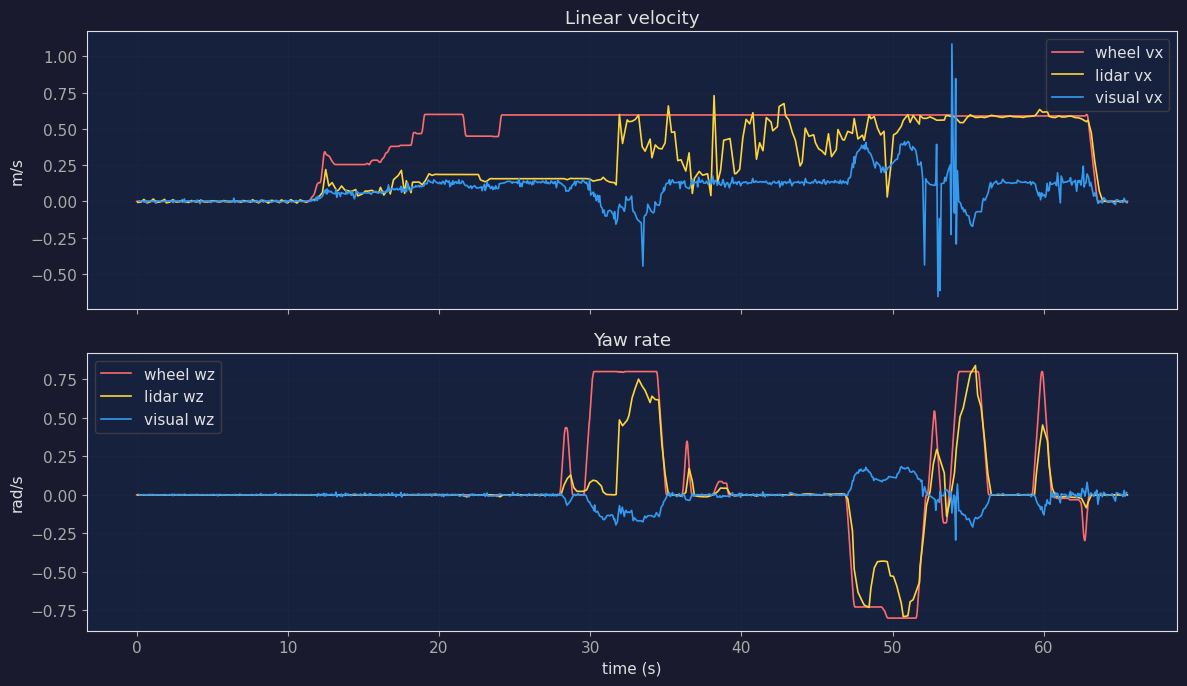

In [54]:
# Velocity comparison
fig, ax = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
colors = {'wheel': '#ff6b6b', 'lidar': '#ffd43b', 'visual': '#339af0'}

for key in ['wheel', 'lidar', 'visual']:
    if key not in dfs:
        continue
    d = dfs[key]
    t = pd.to_numeric(d['t'], errors='coerce').to_numpy()
    vx = pd.to_numeric(d['vx'], errors='coerce').to_numpy()
    wz = pd.to_numeric(d['vyaw'], errors='coerce').to_numpy()
    m1 = np.isfinite(t) & np.isfinite(vx)
    m2 = np.isfinite(t) & np.isfinite(wz)
    ax[0].plot(t[m1], vx[m1], color=colors[key], linewidth=1.2, label=f'{key} vx')
    ax[1].plot(t[m2], wz[m2], color=colors[key], linewidth=1.2, label=f'{key} wz')

ax[0].set_title('Linear velocity')
ax[0].set_ylabel('m/s')
ax[0].grid(True, alpha=0.3)
ax[0].legend()

ax[1].set_title('Yaw rate')
ax[1].set_ylabel('rad/s')
ax[1].set_xlabel('time (s)')
ax[1].grid(True, alpha=0.3)
ax[1].legend()

plt.tight_layout()
save_fig_unique(fig, 'velocity_comparison')
plt.show()

## Detailed VO/LiDAR odometry diagnostics
These plots mirror a practical VO analysis workflow: trajectory shape, speed profile, drift/error against a reference source, and yaw consistency.

In [55]:
def to_xyyaw(df):
    d = df.copy()
    out = pd.DataFrame({
        't': pd.to_numeric(d['t'], errors='coerce'),
        'x': pd.to_numeric(d['x'], errors='coerce'),
        'y': pd.to_numeric(d['y'], errors='coerce'),
        'yaw': pd.to_numeric(d['yaw'], errors='coerce'),
        'vx': pd.to_numeric(d['vx'], errors='coerce'),
        'wz': pd.to_numeric(d['vyaw'], errors='coerce'),
    }).dropna()
    out = out.sort_values('t').drop_duplicates(subset='t')
    return out.reset_index(drop=True)

def wrap_pi(a):
    return (a + np.pi) % (2*np.pi) - np.pi

def cumulative_distance(x, y):
    dx = np.diff(x)
    dy = np.diff(y)
    return np.insert(np.cumsum(np.sqrt(dx*dx + dy*dy)), 0, 0.0)

series = {k: to_xyyaw(v) for k, v in dfs.items() if k in ['wheel', 'lidar', 'visual']}

if 'wheel' not in series:
    raise RuntimeError('wheel odometry not found; cannot compute reference-relative errors.')

# Create common timeline from wheel and interpolate others to it
t_ref = series['wheel']['t'].to_numpy()
aligned = {'wheel': series['wheel'].copy()}

for key in ['lidar', 'visual']:
    if key not in series:
        continue
    s = series[key]
    t = s['t'].to_numpy()
    if len(t) < 3:
        continue
    tmin = max(t_ref.min(), t.min())
    tmax = min(t_ref.max(), t.max())
    m = (t_ref >= tmin) & (t_ref <= tmax)
    if m.sum() < 10:
        continue
    ta = t_ref[m]
    interp = pd.DataFrame({'t': ta})
    for col in ['x', 'y', 'vx', 'wz']:
        interp[col] = np.interp(ta, t, s[col].to_numpy())
    yaw_unwrapped = np.unwrap(s['yaw'].to_numpy())
    interp['yaw'] = np.interp(ta, t, yaw_unwrapped)
    aligned[key] = interp

print('Aligned sources:', list(aligned.keys()))
for k, d in aligned.items():
    print(f'{k:>6s}: {len(d):6d} samples | {d.t.iloc[0]:7.2f} -> {d.t.iloc[-1]:7.2f} s')

Aligned sources: ['wheel', 'lidar', 'visual']
 wheel:   3045 samples |    0.00 ->   65.53 s
 lidar:   3039 samples |    0.08 ->   65.49 s
visual:   3035 samples |    0.15 ->   65.47 s


Saved: /home/rosdata/sensor_run_20260331_014450/plots/detailed_trajectory_diagnostics_1.png


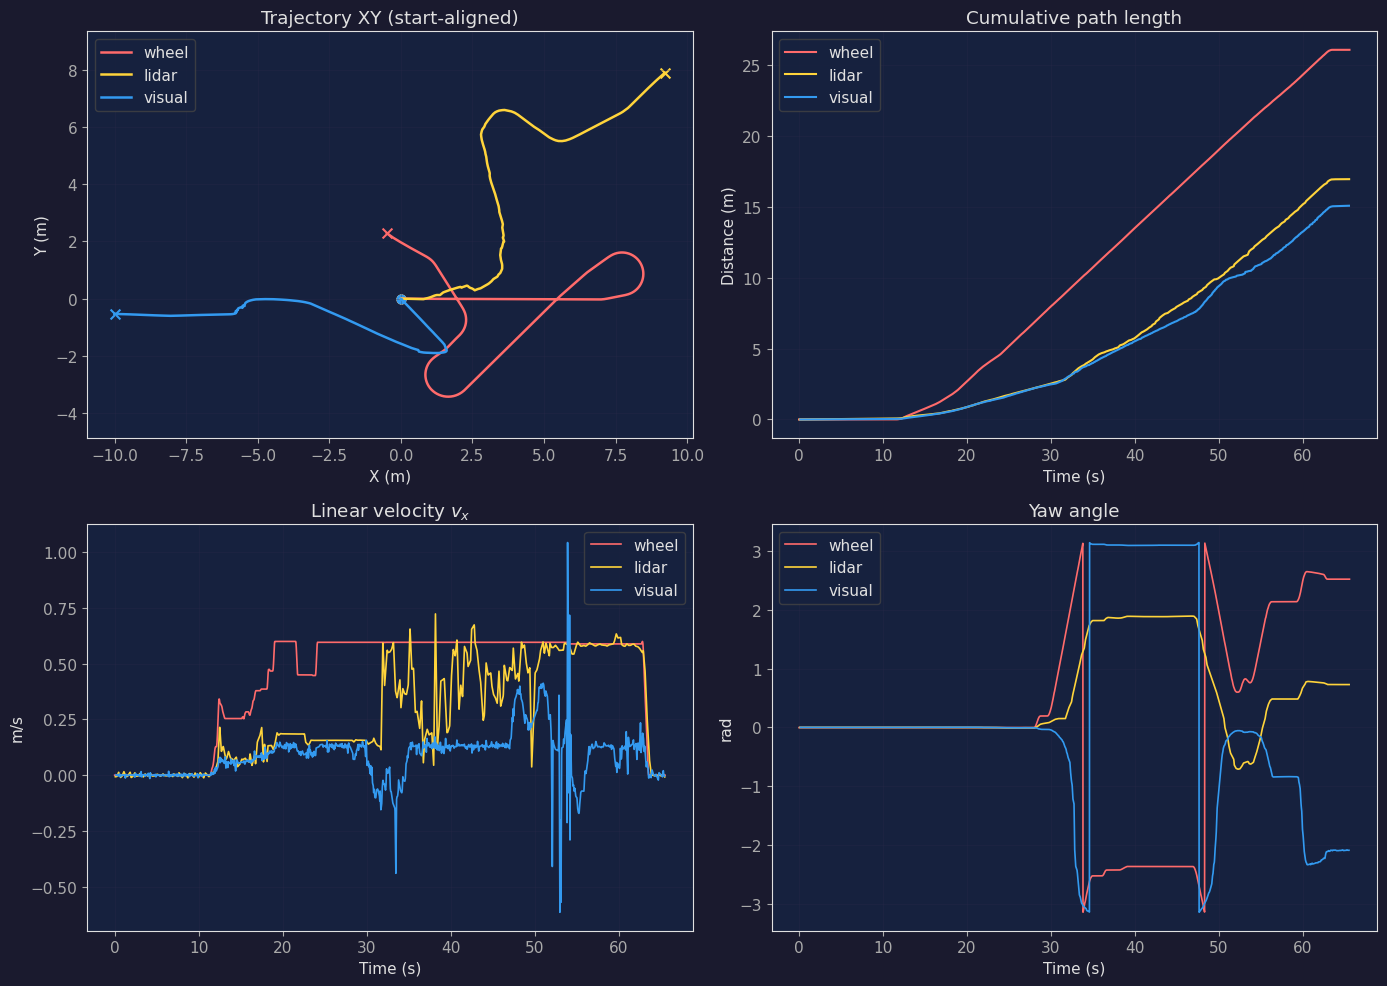

In [56]:
fig, ax = plt.subplots(2, 2, figsize=(14, 10))
clr = {'wheel':'#ff6b6b', 'lidar':'#ffd43b', 'visual':'#339af0'}

# (1) Start-aligned XY trajectory
for k, d in aligned.items():
    x = d['x'].to_numpy() - d['x'].iloc[0]
    y = d['y'].to_numpy() - d['y'].iloc[0]
    ax[0,0].plot(x, y, lw=1.8, color=clr.get(k, None), label=k)
    ax[0,0].scatter([x[0]],[y[0]], marker='o', s=40, color=clr.get(k, None))
    ax[0,0].scatter([x[-1]],[y[-1]], marker='x', s=50, color=clr.get(k, None))
ax[0,0].set_title('Trajectory XY (start-aligned)')
ax[0,0].set_xlabel('X (m)')
ax[0,0].set_ylabel('Y (m)')
ax[0,0].axis('equal')
ax[0,0].grid(True, alpha=0.3)
ax[0,0].legend()

# (2) Cumulative path length
for k, d in aligned.items():
    t = d['t'].to_numpy()
    x = d['x'].to_numpy()
    y = d['y'].to_numpy()
    s = cumulative_distance(x, y)
    ax[0,1].plot(t, s, lw=1.5, color=clr.get(k, None), label=k)
ax[0,1].set_title('Cumulative path length')
ax[0,1].set_xlabel('Time (s)')
ax[0,1].set_ylabel('Distance (m)')
ax[0,1].grid(True, alpha=0.3)
ax[0,1].legend()

# (3) Linear speed profile
for k, d in aligned.items():
    t = d['t'].to_numpy()
    vx = d['vx'].to_numpy()
    ax[1,0].plot(t, vx, lw=1.2, color=clr.get(k, None), label=k)
ax[1,0].set_title('Linear velocity $v_x$')
ax[1,0].set_xlabel('Time (s)')
ax[1,0].set_ylabel('m/s')
ax[1,0].grid(True, alpha=0.3)
ax[1,0].legend()

# (4) Yaw profile
for k, d in aligned.items():
    t = d['t'].to_numpy()
    yw = wrap_pi(d['yaw'].to_numpy())
    ax[1,1].plot(t, yw, lw=1.2, color=clr.get(k, None), label=k)
ax[1,1].set_title('Yaw angle')
ax[1,1].set_xlabel('Time (s)')
ax[1,1].set_ylabel('rad')
ax[1,1].grid(True, alpha=0.3)
ax[1,1].legend()

plt.tight_layout()
save_fig_unique(fig, 'detailed_trajectory_diagnostics')
plt.show()

Saved: /home/rosdata/sensor_run_20260331_014450/plots/error_metrics_diagnostics_1.png


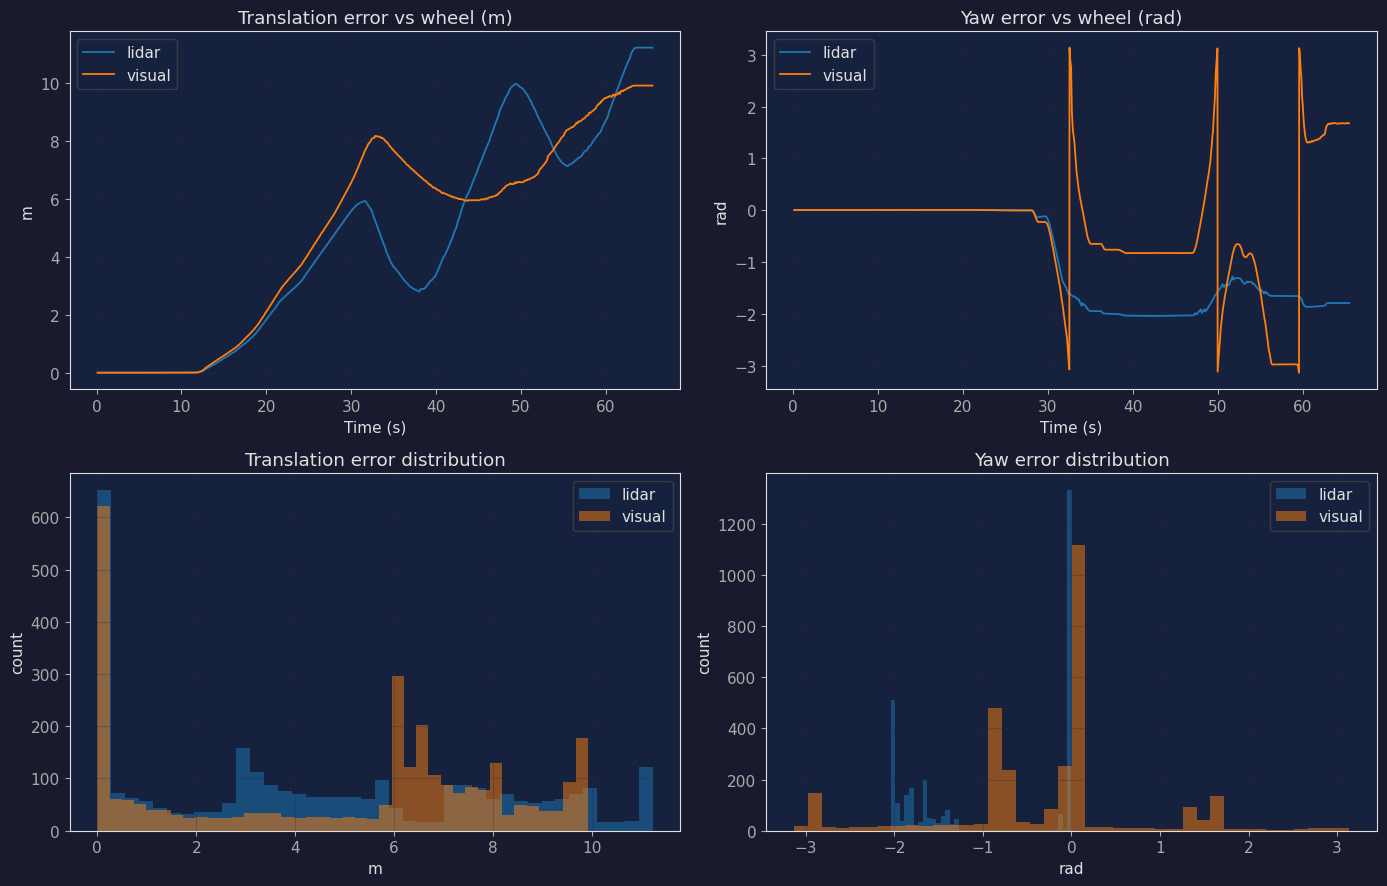

,source,trans_rmse_m,trans_mae_m,yaw_rmse_rad,yaw_mae_rad
0,lidar,5.698638,4.434418,1.301449,0.941868
1,visual,5.897283,4.819451,1.113335,0.701648


In [57]:
ref = aligned['wheel']
ref_t = ref['t'].to_numpy()
ref_x = ref['x'].to_numpy()
ref_y = ref['y'].to_numpy()
ref_yaw = ref['yaw'].to_numpy()

metrics_rows = []

fig, ax = plt.subplots(2, 2, figsize=(14, 9))
targets = [k for k in ['lidar', 'visual'] if k in aligned]

for key in targets:
    d = aligned[key]
    t = d['t'].to_numpy()
    x = d['x'].to_numpy()
    y = d['y'].to_numpy()
    yaw = d['yaw'].to_numpy()

    # Ref is on wheel timeline; match by nearest index length after interpolation stage
    n = min(len(t), len(ref_t))
    ex = x[:n] - ref_x[:n]
    ey = y[:n] - ref_y[:n]
    et = np.sqrt(ex**2 + ey**2)
    eyaw = wrap_pi(yaw[:n] - ref_yaw[:n])

    rmse_t = np.sqrt(np.mean(et**2))
    mae_t = np.mean(np.abs(et))
    rmse_yaw = np.sqrt(np.mean(eyaw**2))
    mae_yaw = np.mean(np.abs(eyaw))

    metrics_rows.append({
        'source': key,
        'trans_rmse_m': rmse_t,
        'trans_mae_m': mae_t,
        'yaw_rmse_rad': rmse_yaw,
        'yaw_mae_rad': mae_yaw,
    })

    ax[0,0].plot(t[:n], et, lw=1.3, label=key)
    ax[0,1].plot(t[:n], eyaw, lw=1.3, label=key)
    ax[1,0].hist(et, bins=40, alpha=0.5, label=key)
    ax[1,1].hist(eyaw, bins=40, alpha=0.5, label=key)

ax[0,0].set_title('Translation error vs wheel (m)')
ax[0,0].set_xlabel('Time (s)')
ax[0,0].set_ylabel('m')
ax[0,0].grid(True, alpha=0.3)
ax[0,0].legend()

ax[0,1].set_title('Yaw error vs wheel (rad)')
ax[0,1].set_xlabel('Time (s)')
ax[0,1].set_ylabel('rad')
ax[0,1].grid(True, alpha=0.3)
ax[0,1].legend()

ax[1,0].set_title('Translation error distribution')
ax[1,0].set_xlabel('m')
ax[1,0].set_ylabel('count')
ax[1,0].grid(True, alpha=0.3)
ax[1,0].legend()

ax[1,1].set_title('Yaw error distribution')
ax[1,1].set_xlabel('rad')
ax[1,1].set_ylabel('count')
ax[1,1].grid(True, alpha=0.3)
ax[1,1].legend()

plt.tight_layout()
save_fig_unique(fig, 'error_metrics_diagnostics')
plt.show()

metrics_df = pd.DataFrame(metrics_rows)
display(metrics_df.sort_values('trans_rmse_m'))

Saved: /home/rosdata/sensor_run_20260331_014450/plots/imu_yaw_rate_consistency_1.png


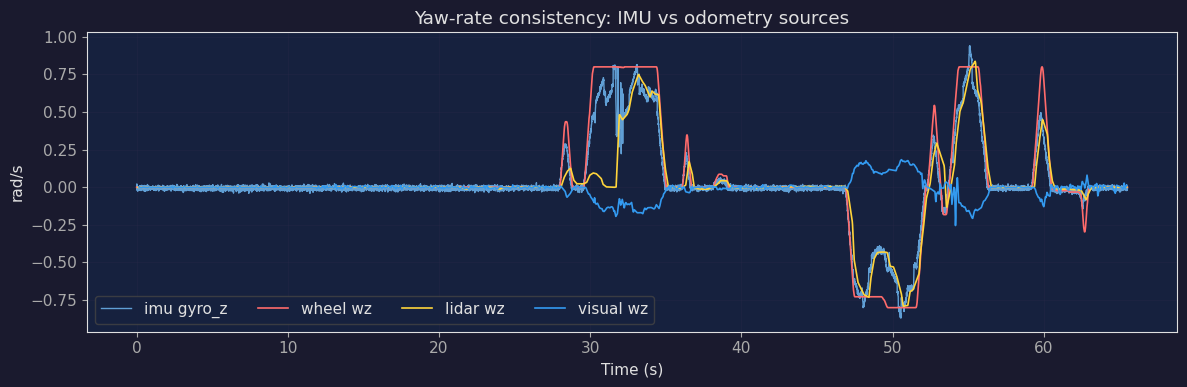

In [58]:
# IMU yaw-rate consistency check
if 'imu' in dfs:
    imu = dfs['imu'].copy()
    imu_t = pd.to_numeric(imu['t'], errors='coerce').to_numpy()
    imu_wz = pd.to_numeric(imu['gyro_z'], errors='coerce').to_numpy()
    m = np.isfinite(imu_t) & np.isfinite(imu_wz)
    imu_t = imu_t[m]
    imu_wz = imu_wz[m]

    fig, ax = plt.subplots(1, 1, figsize=(12, 4))
    ax.plot(imu_t, imu_wz, color='#74c0fc', lw=1.0, alpha=0.8, label='imu gyro_z')
    for key, col in [('wheel', '#ff6b6b'), ('lidar', '#ffd43b'), ('visual', '#339af0')]:
        if key in aligned:
            t = aligned[key]['t'].to_numpy()
            wz = aligned[key]['wz'].to_numpy()
            ax.plot(t, wz, color=col, lw=1.2, label=f'{key} wz')
    ax.set_title('Yaw-rate consistency: IMU vs odometry sources')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('rad/s')
    ax.grid(True, alpha=0.3)
    ax.legend(ncol=4)
    plt.tight_layout()
    save_fig_unique(fig, 'imu_yaw_rate_consistency')
    plt.show()
else:
    print('IMU source not found in dfs.')

## Next step
If these plots are clean, feed `wheel + lidar + visual + imu` into EKF with per-source `*_config` vectors and conservative covariances, then compare `/odometry/filtered` against each source.